# Lab: Machine Learning for Anomalous Property Classification — Part 2

### Preamble

In Part 1, you built a classifier for the National Anomalous Property Register by applying each preprocessing step manually and in sequence: encoding categorical columns, assembling feature vectors, normalising, fitting a model. The result worked, but the steps were scattered across cells and tightly coupled to a particular DataFrame. Running the same preprocessing on new data — say, a fresh batch of field reports from the regional offices — would mean re-executing every cell in the right order and hoping nothing had changed in scope.

Part 2 introduces the **ML Pipeline**: a single object that encapsulates the entire preprocessing and training workflow. Fitting a pipeline on training data produces a `PipelineModel` that can be saved, loaded, and applied to new data with a single `.transform()` call. We also introduce **Word2Vec** for embedding the free-text columns, and **CrossValidator** for systematic hyperparameter search — both of which slot naturally into a pipeline.

## 1. Setup

In [1]:
!pip install pyspark matplotlib scikit-learn "nbformat>=4.2.0" --quiet

In [6]:
import math
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, lit, size, concat_ws, split
from pyspark.sql.types import IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (StringIndexer, OneHotEncoder, VectorAssembler, 
                                Imputer, MinMaxScaler, Word2Vec, Tokenizer, PCA)
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, ClusteringEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.stat import Summarizer

spark = SparkSession.builder.getOrCreate()


## 2. Loading the Dataset

We load the same NAPR Parquet file from Part 1 and apply the same light preprocessing — null drop, derived features, boolean and target casting — in a single consolidated block. This is boilerplate you have already seen; run it and move on.

In [3]:
properties = spark.read.parquet("haunted_houses.parquet")
properties.count(), len(properties.columns)

(5000, 26)

In [7]:
# Null drop, derived features, cast target — identical to Part 1
properties = properties.na.drop()

CURRENT_YEAR = 2026
properties = properties \
    .withColumn("property_age", lit(CURRENT_YEAR) - col("construction_date")) \
    .withColumn("sightings_count", size(split(col("sightings"), r"\|")))

bool_cols = ["warning", "teenage_group_disappearance", "foggy", "belltower", "moor_nearby"]
for c in bool_cols:
    properties = properties.withColumn(c, col(c).cast(IntegerType()))
properties = properties.withColumn("haunted", col("haunted").cast(IntegerType()))

TARGET = "haunted"

properties.count()  # records remaining after null drop


4987

## 3. Transformers and Estimators

Before building a pipeline, it helps to be precise about the two kinds of objects it can contain.

**Transformer** — has only a `transform(df)` method. It applies a fixed, data-independent operation: `VectorAssembler`, `OneHotEncoder` (after fitting), `Tokenizer`. No learning happens; the same logic applies to any DataFrame.

**Estimator** — has a `fit(df)` method that *learns* something from the data and returns a fitted **transformer** (a `Model`). Examples: `StringIndexer`, `Imputer`, `MinMaxScaler`, `Word2Vec`, `LogisticRegression`. You must call `.fit()` before you can call `.transform()`.

The distinction matters because a `Pipeline` handles them differently under the hood: for each stage it calls `fit()` if the stage is an estimator, `transform()` if it is a transformer, passing the output of one stage as the input to the next.

### Data contamination

Estimators *learn from whatever data you pass to `.fit()`*. If you fit an `Imputer` or `MinMaxScaler` on the full dataset before splitting, the learned statistics (mean, min, max) will reflect test-set values too — the model has indirectly 'seen' the test set before evaluation. This is **data leakage**, and it produces optimistically biased metrics.

The correct discipline is: **fit only on training data, transform both splits**.

```python
# Wrong — leaks test statistics into the fitted parameters
imputer_model = imputer.fit(full_dataset)

# Correct — learns only from training data
imputer_model = imputer.fit(training)
train_imputed = imputer_model.transform(training)
test_imputed  = imputer_model.transform(test)
```

### Is there a `fit_transform()` like in scikit-learn?

No. Spark ML does not have `fit_transform()`, and the `Pipeline` object is the idiomatic replacement. Calling `pipeline.fit(training)` fits every estimator stage on the training data, producing a `PipelineModel`. That model is then a pure transformer: `pipeline_model.transform(test)` applies all stages — with the parameters learned from training — to the test set without refitting anything.

## 4. Building a Pipeline

A `Pipeline` is itself an estimator whose only parameter is `stages`: an ordered list of transformers and estimators. Calling `.fit()` on a Pipeline produces a `PipelineModel`, which is a transformer. That `PipelineModel` can then be applied to new data with a single `.transform()` call — the entire preprocessing chain runs automatically in the correct order.

This is the key practical advantage over Part 1's manual approach: the pipeline guarantees that test data and any future production data go through exactly the same transformations as the training data, fitted on the training data only.

### 4.1 Preprocessing stages

We define each preprocessing stage as a named variable. The boilerplate (column lists, output column names) is filled in; fill in the missing estimator and transformer definitions.

**TODO:**
- Instantiate `StringIndexer` for `phenomenon_type` and `ghost`.
- Instantiate `OneHotEncoder` on the resulting index columns.
- Instantiate `Imputer` with `strategy="mean"` on the numeric columns.
- Instantiate `MinMaxScaler` to bring the assembled numeric vector to [0, 1].
- Instantiate the final `VectorAssembler` that combines scaled numerics, boolean flags, and OHE vectors into `"features"`.

In [8]:
# --- Categorical encoding ---
indexer = StringIndexer(
    inputCols     = ["phenomenon_type", "ghost"],
    outputCols    = ["phenomenon_idx", "ghost_idx"],
    handleInvalid = "keep",
)

encoder = OneHotEncoder(
    inputCols  = ["phenomenon_idx", "ghost_idx"],
    outputCols = ["phenomenon_vec", "ghost_vec"],
)

# --- Numeric imputation ---
numeric_cols = [
    "property_age", "sightings_count",
    "owl_hoots", "villagers_count", "disappeared_visitors",
    "dread", "tripadvisor_stars", "insurance_exclusion_clauses",
]
numeric_cols_imputed = [c + "_i" for c in numeric_cols]

imputer = Imputer(
    strategy   = "mean",
    inputCols  = numeric_cols,
    outputCols = numeric_cols_imputed,
)

# --- Scaling: bring all numeric features to [0, 1] ---
numeric_assembler = VectorAssembler(inputCols=numeric_cols_imputed, outputCol="numeric_raw")

scaler = MinMaxScaler(inputCol="numeric_raw", outputCol="numeric_scaled")

# --- Final feature assembly ---
feature_assembler = VectorAssembler(
    inputCols = ["numeric_scaled"] + bool_cols + ["phenomenon_vec", "ghost_vec"],
    outputCol = "features",
)

### 4.2 Assembling and fitting the pipeline

We pass the stages in order to `Pipeline`, then fit on the training set. Note that we split *before* fitting — the pipeline must never see the test set during training, including during the `Imputer` and `MinMaxScaler` fitting steps.

In [9]:
training, test = [df.cache() for df in properties.randomSplit([0.7, 0.3], seed=753)]
training.count(); test.count()  # trigger cache materialisation

1508

In [10]:
# Concrete example: VectorAssembler is a transformer — no fit() needed
demo_assembler = VectorAssembler(
    inputCols=["owl_hoots", "dread", "tripadvisor_stars"],
    outputCol="demo_features",
)
demo_assembler.explainParam("outputCol")

# Imputer is an estimator — it must be fitted, and only on training data.
# Fitting on the full dataset would leak test-set statistics. Note that
# the training DataFrame is defined in Section 4 — run that cell first
# if you want to execute this demo independently.
demo_imputer = Imputer(
    strategy   = "mean",
    inputCols  = ["owl_hoots", "dread"],
    outputCols = ["owl_hoots_i", "dread_i"],
)
demo_imputer_model = demo_imputer.fit(training)

# Show what the imputer learned: the mean of each column on the training set.
# These are the values that will fill nulls at transform time.
training.agg(
    {"owl_hoots": "mean", "dread": "mean"}
).show()


+------------------+----------------+
|        avg(dread)|  avg(owl_hoots)|
+------------------+----------------+
|35.691824950710405|51.2417268710502|
+------------------+----------------+



In [11]:
lr = LogisticRegression(featuresCol="features", labelCol=TARGET)

pipeline = Pipeline(stages=[
    indexer,
    encoder,
    imputer,
    numeric_assembler,
    scaler,
    feature_assembler,
    lr,
])

pipeline_model = pipeline.fit(training)

26/04/21 18:29:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


In [12]:
results = pipeline_model.transform(test)
results.select("prediction", "probability", TARGET).show(5, truncate=50)

+----------+-----------------------------------------+-------+
|prediction|                              probability|haunted|
+----------+-----------------------------------------+-------+
|       0.0|   [0.99066239121518,0.00933760878482004]|      0|
|       0.0|[0.9855430302398107,0.014456969760189287]|      0|
|       0.0|[0.9814469050333788,0.018553094966621164]|      0|
|       1.0|  [0.3249303674571032,0.6750696325428969]|      0|
|       0.0|[0.9871226110023142,0.012877388997685757]|      0|
+----------+-----------------------------------------+-------+
only showing top 5 rows


### 4.3 Evaluating the pipeline model

We can extract individual fitted stages from the `PipelineModel` using `.stages`, which mirrors the order of stages passed to the pipeline.

In [13]:
evaluator = BinaryClassificationEvaluator(labelCol=TARGET, metricName="areaUnderROC")
auc_pipeline = evaluator.evaluate(results)
print(f"Pipeline LR — Test AUC-ROC: {auc_pipeline:.4f}")

# Extract the fitted LR model from the last stage
lr_model = pipeline_model.stages[-1]
metrics  = lr_model.evaluate(results.select(TARGET, "features"))
print(f"Precision (haunted=1): {metrics.precisionByLabel[1]:.4f}")
print(f"Recall    (haunted=1): {metrics.recallByLabel[1]:.4f}")

Pipeline LR — Test AUC-ROC: 0.8904
Precision (haunted=1): 0.6857
Recall    (haunted=1): 0.4404


In [14]:
# Confusion matrix
results.groupBy(TARGET).pivot("prediction").count().show()

+-------+----+---+
|haunted| 0.0|1.0|
+-------+----+---+
|      1| 122| 96|
|      0|1246| 44|
+-------+----+---+



## 5. Saving and Loading a Pipeline

A fitted `PipelineModel` can be written to disk and reloaded later. This is how a trained model moves from a training notebook to a production scoring job — the loaded model is a fully functional transformer that applies all stages to new data with a single `.transform()` call, with no retraining.

In [15]:
pipeline_model.write().overwrite().save("./hmspia_pipeline_lr")

from pyspark.ml import PipelineModel
loaded_model = PipelineModel.load("./hmspia_pipeline_lr")
auc_loaded = evaluator.evaluate(loaded_model.transform(test))
print(f"AUC from loaded pipeline: {auc_loaded:.4f}  (should match {auc_pipeline:.4f})")

AUC from loaded pipeline: 0.8904  (should match 0.8904)


## 6. Hyperparameter Tuning with CrossValidator

`CrossValidator` wraps a pipeline (or any estimator) and a grid of hyperparameter values, refitting the pipeline once for each combination across K folds of the training data. It returns the best model according to the evaluator metric.

`ParamGridBuilder` constructs the grid. Each `.addGrid(param, values)` call adds one hyperparameter with a list of candidate values; the builder takes the Cartesian product across all added parameters.

Note: Spark ML has no random grid search equivalent. `ParamGridBuilder` always evaluates the full Cartesian product.

In [16]:
# 1. Define the Preprocessing Pipeline
# This stage handles all feature engineering: indexing, encoding, imputing, and scaling.
# Nested pipelines allow for cleaner separation between feature prep and model training.
preprocess_pipeline = Pipeline(stages=[
    indexer, encoder, imputer, numeric_assembler, scaler, feature_assembler
])

# 2. Initialize the Estimator
# We use Logistic Regression as our base learner, targeting the 'TARGET' label.
lr_crossval = LogisticRegression(featuresCol="features", labelCol=TARGET)

# 3. Create the Full Cross-Validation Pipeline
# By nesting the preprocessing pipeline, we ensure that every fold of cross-validation 
# re-runs the preprocessing to prevent data leakage from the validation sets.
crossval_pipeline = Pipeline(stages=[preprocess_pipeline, lr_crossval])

# 4. Construct the Parameter Grid
# We explore combinations of regularization (regParam) and the L1/L2 mix (elasticNetParam).
# .build() generates the cartesian product of these parameters.
param_grid = (
    ParamGridBuilder()
    .addGrid(lr_crossval.regParam,        [0.01, 0.1])
    .addGrid(lr_crossval.elasticNetParam, [0.0,  1.0])
    .build()
)

# 5. Configure the Cross-Validator
# Estimator: The pipeline to be tuned.
# numFolds: Splits the training data into 3 parts; rotates 1 for validation and 2 for training.
cross_validator = CrossValidator(
    estimator          = crossval_pipeline,
    estimatorParamMaps = param_grid,
    evaluator          = evaluator,
    numFolds           = 3,
    seed               = 753,
)

# 6. Fit and Evaluate
# This triggers (numFolds * numParamCombinations) training runs.
cross_validator_model = cross_validator.fit(training)
crossval_results      = cross_validator_model.transform(test)
auc_cv                = evaluator.evaluate(crossval_results)

print(f"Cross-validated AUC-ROC: {auc_cv:.4f}")
print(f"Avg metrics per fold:    {[round(m, 4) for m in cross_validator_model.avgMetrics]}")


Cross-validated AUC-ROC: 0.8919
Avg metrics per fold:    [0.8761, 0.8836, 0.8803, 0.8311]


In [18]:
# The best model is accessible directly
best_pipeline = cross_validator_model.bestModel
best_lr       = best_pipeline.stages[-1]   # LR is last stage of inner pipeline
print(f"Best regParam:        {best_lr.getRegParam()}")
print(f"Best elasticNetParam: {best_lr.getElasticNetParam()}")

Best regParam:        0.01
Best elasticNetParam: 1.0


## 7. Word2Vec for Text Features

In Part 1 Section 8.3 we used TF-IDF to incorporate free-text columns. TF-IDF is a bag-of-words approach: it counts words but ignores their meaning and order. **Word2Vec** is a shallow neural network that instead learns a dense vector representation (an *embedding*) for each word such that semantically similar words sit close together in vector space.

Spark ML's `Word2Vec` takes a column of token arrays and returns, for each document, the **average** of its word vectors — a single dense vector regardless of document length. This is cruder than transformer-based embeddings but fast and entirely Spark-native.

Key parameters:
- `vectorSize` — dimensionality of each word embedding (default 100).
- `minCount` — words appearing fewer than this many times are ignored.
- `windowSize` — context window used during training.
- `inputCol` — must be an array of strings (i.e. already tokenized).
- `outputCol` — the resulting dense vector column.

### 7.1 Preparing text columns

Word2Vec expects tokenised input — an array of strings per row. We use `Tokenizer` (lowercases and splits on whitespace) and then concatenate all four text columns into a single token array before embedding.

In [19]:
# These are the free-text columns of our dataset
TEXT_COLS = [
    "estate_agent_euphemism", "cat_behaviour",
    "vicar_response", "most_recent_excuse",
    "previous_owners_fate", "archaeology_report_status"
]

# Fill nulls so Tokenizer doesn't fail, then concatenate into one string
data_text = properties
for text_col in TEXT_COLS:
    data_text = data_text.fillna("", subset=[text_col])

data_text = data_text.withColumn(
    "all_text",
    concat_ws(" ", *[col(text_col) for text_col in TEXT_COLS])
)

tokenizer = Tokenizer(inputCol="all_text", outputCol="text_tokens")
data_text = tokenizer.transform(data_text)
data_text.select("text_tokens").show(3, truncate=80)

+--------------------------------------------------------------------------------+
|                                                                     text_tokens|
+--------------------------------------------------------------------------------+
|[heatherside, place, offers, the, discerning, buyer, a, rare, opportunity, to...|
|[ashenmoor, folly, commands, an, enviable, position, above, kyle, of, lochals...|
|[everwood, gables,, constructed, in, 1374,, presents, a, splendid, prospect, ...|
+--------------------------------------------------------------------------------+
only showing top 3 rows


### 7.2 Fitting Word2Vec as a standalone estimator

Before plugging Word2Vec into a pipeline, we inspect it in isolation to understand what it learns. After fitting we can query the model for the words most similar to a given word — a useful sanity check.

In [20]:
word2vec = Word2Vec(
    vectorSize = 150,
    minCount   = 3,
    windowSize = 5,
    inputCol   = "text_tokens",
    outputCol  = "text_embedding",
    seed       = 753,
)

word2vec_model = word2vec.fit(data_text)

# Inspect the learned vocabulary — find words similar to 'vicar'
word2vec_model.findSynonyms("vicar", 5).show(truncate=False)

+---------+------------------+
|word     |similarity        |
+---------+------------------+
|reverend |0.8717876672744751|
|rector   |0.8489974737167358|
|minister |0.8340692520141602|
|clergyman|0.7589829564094543|
|canon    |0.7477121353149414|
+---------+------------------+



In [21]:
# Transform: each document becomes the mean of its word vectors
data_text = word2vec_model.transform(data_text)
data_text.select("text_embedding").show(3, truncate=80)

+--------------------------------------------------------------------------------+
|                                                                  text_embedding|
+--------------------------------------------------------------------------------+
|[0.018545150966383518,0.020277253212407233,0.01801291061192751,0.006420310726...|
|[-0.045531577519362876,0.05610150263029416,0.043644133627706666,-0.0208821320...|
|[-0.011813557469369178,0.02712712976249999,0.05830099374912347,-0.01574417927...|
+--------------------------------------------------------------------------------+
only showing top 3 rows


### 7.2.1 Which text column matters most?

Before building the full pipeline, it is worth asking whether all four text columns carry equal predictive weight, or whether one dominates.

**The approach.** For each column *in isolation* we:
1. Tokenise it.
2. Fit a Word2Vec model on the training split of that column alone.
3. Transform both splits to get a document-level embedding (the mean of its token vectors).
4. Assemble that single embedding into `features` and train a Logistic Regression.
5. Record the AUC on the test split.

**What this is and isn't.** This is a *marginal contribution* screen — each column is tested in isolation, so interaction effects are ignored. It is a fast, interpretable guide for deciding which columns to invest in further (e.g. with a larger `vectorSize`, more preprocessing, or a dedicated PCA stage). It does **not** tell you the column's contribution inside a joint model, where a weaker column may still add signal that the others lack.

**TODO:** Complete the loop. For each `text_col` in `TEXT_COLS`:
1. Tokenise it with `Tokenizer` into `"single_column_tokens"`.
2. Fit `Word2Vec` (vectorSize=150, minCount=2, seed=753) on the training split.
3. Transform both splits; assemble the embedding into `"features"` with `VectorAssembler`.
4. Fit `LogisticRegression` and evaluate AUC on the test split; store it in `column_auc_scores`.

Which column wins? Does the result match your intuition about the dataset?

In [22]:
auc_scores_by_column = {}

for text_col in TEXT_COLS:
    column_data = properties.fillna("", subset=[text_col])

    tokenizer   = Tokenizer(inputCol=text_col, outputCol="single_column_tokens")
    column_data = tokenizer.transform(column_data)

    train_data, test_data = [df.cache() for df in column_data.randomSplit([0.7, 0.3], seed=753)]
    train_data.count(); test_data.count()

    word2vec = Word2Vec(
        vectorSize = 150,
        minCount   = 2,
        inputCol   = "single_column_tokens",
        outputCol  = "column_embedding",
        seed       = 753,
    )
    word2vec_model = word2vec.fit(train_data)
    train_embedded = word2vec_model.transform(train_data)
    test_embedded  = word2vec_model.transform(test_data)

    assembler      = VectorAssembler(inputCols=["column_embedding"], outputCol="features")
    train_embedded = assembler.transform(train_embedded)
    test_embedded  = assembler.transform(test_embedded)

    logistic_regression = LogisticRegression(featuresCol="features", labelCol=TARGET)
    lr_model            = logistic_regression.fit(train_embedded)

    auc_score = evaluator.evaluate(lr_model.transform(test_embedded))
    auc_scores_by_column[text_col] = round(auc_score, 4)

    train_data.unpersist(); test_data.unpersist()

for text_col, auc_score in sorted(auc_scores_by_column.items(), key=lambda x: x[1], reverse=True):
    print(f"{text_col:35s}  AUC = {auc_score:.4f}")


estate_agent_euphemism               AUC = 0.8008


### 7.2.2 Vector arithmetic: exploring the embedding space

Word2Vec encodes semantic relationships as **directions** in vector space. The canonical demonstration is an analogy task: if the model has learned a consistent direction for a relationship, arithmetic on vectors should land near the expected answer.

A well-known example from generic corpora is the *country → capital* relationship:

> `vec(France) − vec(Paris) ≈ vec(Germany) − vec(Berlin)`  
> equivalently: `vec(Germany) − vec(Berlin) + vec(Paris) ≈ vec(France)`

Our corpus has its own consistent relationships across four distinct registers — the estate agent's euphemisms, the vicar's responses, the cat's behaviour, and the excuses offered by previous occupants. Good analogies exploit the *contrast between registers*:

| Column | Analogy | Intuition |
|---|---|---|
| Estate agent euphemism | `poltergeist − haunted + potential ≈ ?` | What does an agent call a poltergeist? |
| Owner Excuse | `ghost − haunted + pipes ≈ ?` | The same phenomenon, rationalised as a plumbing issue |
| Cat behaviour | `cat − ghost + interest ≈ ?` | If not a ghost, what is the resident cat then interested in? |

The arithmetic works as follows: given `positive` words (add) and `negative` words (subtract), compute a result vector, then call `findSynonyms` with it — `findSynonyms` accepts either a word **string** *or* a raw `DenseVector`.

> **Note on expectations.** The corpus is not enormous, so not every analogy will resolve cleanly — that is a valid and interesting result in itself. If a query word is missing from the vocabulary, `analogy()` will tell you. Try browsing `vocab.keys()` to find words that are actually present before designing your own experiments.

**TODO:**
1. Run at least **three** analogy experiments using `analogy()`. Start with the examples in the table above, then design one of your own.
2. Use `cosine_sim()` to evaluate at least **four** word pairs. Which are closest? Are any results surprising?


In [25]:
# Retrieve all word vectors from the trained Word2Vec model
vocabulary_df = word2vec_model.getVectors()

def get_vector(word):
    # Filter the vocabulary for a specific word and extract its vector
    row = vocabulary_df.filter(col("word") == word).first()
    return row["vector"] if row else None

In [58]:
from pyspark.ml.stat import Summarizer
from pyspark.sql.functions import udf, sum
from pyspark.ml.linalg import VectorUDT, Vectors

# Define a UDF to multiply a vector by a scalar
multiply_vector_by_scalar = udf(
    lambda vector, scalar: Vectors.dense([scalar * x for x in vector.toArray()]),
    VectorUDT()
)

def analogy(positive, negative=None, k=5):
    negative = negative or []
    weights = [(w, 1.0) for w in positive] + [(w, -1.0) for w in negative]

    # Create a DataFrame with words and their weights
    weights_df = spark.createDataFrame(weights, ["word", "weight"])

    # Join with vocabulary and multiply each vector by its weight
    weighted_vectors = vocabulary_df.join(weights_df, on="word") \
        .withColumn("vector_weighted", multiply_vector_by_scalar(col("vector"), col("weight")))

    # Sum all weighted vectors
    res = weighted_vectors.select(Summarizer.sum(col("vector_weighted"))).first()

    if not res or res[0] is None:
        return None

    # Filter out the original input words from the similarity search
    exclude = set(positive + negative)
    return word2vec_model.findSynonyms(res[0], k + len(exclude)) \
        .filter(~col("word").isin(list(exclude))).limit(k)

# Example usage
analogy(positive=["poltergeist", "potential"], negative=["haunted"]).show()

26/04/21 18:50:37 WARN TaskSetManager: Stage 851 contains a task of very large size (1627 KiB). The maximum recommended task size is 1000 KiB.


+---------------+------------------+
|           word|        similarity|
+---------------+------------------+
|      interests|0.9059593081474304|
|       suitable|0.9021549820899963|
|philosophically| 0.901279628276825|
|     unbothered|0.8991011381149292|
|          ideal|0.8958449959754944|
+---------------+------------------+



In [59]:
# Experiment B — supernatural phenomenon → mundane excuse
analogy(positive=["ghost", "pipes"], negative=["haunted"]).show()


26/04/21 18:50:42 WARN TaskSetManager: Stage 855 contains a task of very large size (1627 KiB). The maximum recommended task size is 1000 KiB.


+------------+------------------+
|        word|        similarity|
+------------+------------------+
|      lynton|0.8695536851882935|
|shaftesbury,|0.8573111295700073|
|    sweeping|0.8295001983642578|
|   rothbury,|0.8136806488037109|
|     lynton,|0.7979592084884644|
+------------+------------------+



In [60]:
# Experiment C — feline alarm → feline curiosity
analogy(positive=["cat", "interest"], negative=["ghost"]).show()


26/04/21 18:50:43 WARN TaskSetManager: Stage 859 contains a task of very large size (1627 KiB). The maximum recommended task size is 1000 KiB.


+--------------+------------------+
|          word|        similarity|
+--------------+------------------+
|  significance|0.9413051605224609|
| significance.|0.9193049669265747|
|        depth,| 0.901695966720581|
| significance,|0.8958346247673035|
|(documentation|0.8852401971817017|
+--------------+------------------+



In [69]:
def cosine_sim(w1, w2):
    """Spark-native similarity using **0.5 for square root to avoid math import."""
    v1, v2 = get_vector(w1), get_vector(w2)
    if not v1 or not v2: return 0.0
    
    dot = v1.dot(v2)
    norm1 = v1.dot(v1)**0.5
    norm2 = v2.dot(v2)**0.5
    
    return float(dot / (norm1 * norm2)) if (norm1 * norm2) > 0 else 0.0

pairs = [("haunted", "potential"), ("house", "mansion"), ("ghost", "poltergeist")]
for w1, w2 in pairs:
    print(f"cos({w1:12s}, {w2:12s}) = {cosine_sim(w1, w2):.4f}")


cos(haunted     , potential   ) = 0.4208
cos(house       , mansion     ) = 0.9128
cos(ghost       , poltergeist ) = 0.0000


### 7.2.3 Clustering the vocabulary with KMeans

Vector arithmetic probes *specific* relationships. Clustering takes a broader view: it partitions the entire vocabulary into groups of semantically close words, without any prior hypothesis about which words belong together.

Spark ML's `KMeans` is an estimator that works on any `DenseVector` column — the same interface as the rest of the pipeline. We fit it directly on `vectors_df` (the vocabulary DataFrame returned by `getVectors()`).

The key design choice is **k** — the number of clusters. Use the **silhouette score** (`ClusteringEvaluator` with `metricName="silhouette"`, `distanceMeasure="cosine"`) to compare candidate values: +1 is perfect separation, 0 means overlapping, −1 means misclustered.

To inspect a fitted cluster, a useful summary is the **words closest to its centroid** — those are the most representative members. `cluster_label()` below does this: given a cluster id and a fitted model, it computes cosine distances from all member words to the centroid and returns the top-n closest.

**TODO:**
1. Complete `cluster_label()` — the centroid retrieval and distance computation are stubbed out.
2. Sweep `k ∈ {5, 8, 12, 16, 20}`, record silhouette scores, and identify the best k.
3. Refit with the best k and call `cluster_label()` on every cluster. Can you assign a human-readable theme to each?

Consider: what makes a cluster thematically incoherent? How does increasing k trade interpretability for granularity?


In [70]:
# Prepare data for clustering by renaming the vector column to 'features'
clustering_df = vocabulary_df.withColumnRenamed("vector", "features")

def cluster_label(cluster_id, model, data, n=8):
    # 1. Get the centroid for the specific cluster
    centroid = model.clusterCenters()[cluster_id]
    # 2. Collect all words assigned to this cluster
    members = [r for r in data.collect() if r["prediction"] == cluster_id]
    
    def sim(v1, v2):
        # Manual cosine similarity: (A . B) / (||A|| * ||B||)
        # Using **0.5 instead of math.sqrt
        dot = float(v1.dot(v2))
        norm1 = float(v1.dot(v1))**0.5
        norm2 = float(v2.dot(v2))**0.5
        return dot / (norm1 * norm2) if (norm1 * norm2) > 0 else 0.0
        
    # 3. Sort by proximity to centroid
    members.sort(key=lambda r: sim(r["features"], centroid), reverse=True)
    return [r["word"] for r in members[:n]]

# Sweep k values to find the best clustering configuration
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="cosine")
scores = {}
for k in [5, 8, 12, 16, 20]:
    km = KMeans(featuresCol="features", k=k, seed=753).fit(clustering_df)
    scores[k] = evaluator.evaluate(km.transform(clustering_df))

# Display Silhouette scores for comparison
spark.createDataFrame(list(scores.items()), ["k", "silhouette"]).show()

# Finalize model with the best k found
best_k = max(scores, key=scores.get)
best_km = KMeans(featuresCol="features", k=best_k, seed=753).fit(clustering_df)
results = best_km.transform(clustering_df)

# Display representative words for each cluster using a Spark DataFrame
summary = [(i, ", ".join(cluster_label(i, best_km, results))) for i in range(best_k)]
spark.createDataFrame(summary, ["cluster", "representative_words"]).show(truncate=False)


26/04/21 18:53:58 WARN TaskSetManager: Stage 875 contains a task of very large size (1603 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:53:58 WARN TaskSetManager: Stage 878 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:53:59 WARN TaskSetManager: Stage 879 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:53:59 WARN TaskSetManager: Stage 880 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:53:59 WARN TaskSetManager: Stage 881 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:53:59 WARN TaskSetManager: Stage 882 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:53:59 WARN TaskSetManager: Stage 883 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.

+---+--------------------+
|  k|          silhouette|
+---+--------------------+
|  5|-0.12101591793789616|
|  8| -0.3212316561683702|
| 12| -0.3025032629063878|
| 16|-0.32017238793187663|
| 20|-0.33458642826030216|
+---+--------------------+



26/04/21 18:54:12 WARN TaskSetManager: Stage 1168 contains a task of very large size (1603 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:54:12 WARN TaskSetManager: Stage 1171 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:54:12 WARN TaskSetManager: Stage 1172 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:54:12 WARN TaskSetManager: Stage 1173 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:54:12 WARN TaskSetManager: Stage 1174 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:54:12 WARN TaskSetManager: Stage 1175 contains a task of very large size (1613 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 18:54:12 WARN TaskSetManager: Stage 1176 contains a task of very large size (1613 KiB). The maximum recommended task size is 10

+-------+---------------------------------------------------------------------------------+
|cluster|representative_words                                                             |
+-------+---------------------------------------------------------------------------------+
|0      |discerning, purchaser, buyer, buyer:, rare, opportunity, ideal, seeking          |
|1      |lair,, structure, keep,, house,, 1265, formidable, gem, pile,                    |
|2      |government, never, archival, planning, methodology, somewhat, while, sufficiently|
|3      |temperament., us, forwarding, perhaps, witnessed, temporal, paperwork, pipe-organ|
|4      |two, protective, nine, comprehensive, twelve, eleven, addressing, three          |
+-------+---------------------------------------------------------------------------------+



### 7.3 Word2Vec + PCA inside a pipeline

In Section 7.2.1 you ranked the four text columns by standalone AUC. Use that result here: rather than concatenating all four columns blindly, choose which to include based on what you found.

**The dimensionality problem.** With `vectorSize=150`, the Word2Vec block contributes 150 dimensions to the final feature vector while the entire numeric and boolean block contributes roughly 20. A Random Forest sees far more candidate split points in the text block, which can crowd out the structured features even if they carry more signal.

**The fix: PCA.** We add a `PCA` stage immediately after `Word2Vec` to compress the 150-dimensional embedding down to `k` principal components — retaining most of the variance while bringing the text block back to a comparable scale. `PCA` is an estimator in `pyspark.ml.feature`: it fits on the training data to learn the principal directions, then transforms both splits.

**TODO:**
1. Choose `best_text_col` from your Section 7.2.1 ranking.
2. Set `k` — the number of PCA components to keep. Start with 20 and experiment.
3. Assemble the pipeline stages and assign to `word2vec_pipeline`.
4. Fit, transform, and compare AUC to the numeric-only baseline.

In [ ]:
def run_w2v_pipeline(df, text_col, label, pca_k=20, seed=753):
    """Encapsulates the W2Vec + PCA + Random Forest workflow into a single function."""
    tokenizer = Tokenizer(inputCol=text_col, outputCol="tokens")
    w2v = Word2Vec(vectorSize=150, minCount=3, inputCol="tokens", outputCol="w2v", seed=seed)
    pca = PCA(k=pca_k, inputCol="w2v", outputCol="pca")
    
    # Assemble text features (PCA) with numeric and boolean features
    assembler = VectorAssembler(
        inputCols = ["numeric_scaled"] + bool_cols + ["phenomenon_vec", "ghost_vec", "pca"],
        outputCol = "features"
    )
    
    rf = RandomForestClassifier(featuresCol="features", labelCol=TARGET, numTrees=100, maxDepth=5, seed=seed)
    
    # Define the full Pipeline stage sequence
    pipeline = Pipeline(stages=[indexer, encoder, imputer, numeric_assembler, scaler, tokenizer, w2v, pca, assembler, rf])
    
    train, test = [d.cache() for d in df.randomSplit([0.7, 0.3], seed=seed)]
    model = pipeline.fit(train)
    
    # Evaluate performance using AUC-ROC
    evaluator = BinaryClassificationEvaluator(labelCol=TARGET)
    auc = evaluator.evaluate(model.transform(test))
    
    train.unpersist(); test.unpersist()
    print(f"{label:40s} AUC: {auc:.4f}")
    return auc, model


# Run pipeline. Use ``estate_agent_euphemism`` as example
auc_w2v, w2v_pipeline_model = run_w2v_pipeline(properties, "estate_agent_euphemism", "RF + Word2Vec + PCA")

26/04/21 18:55:48 WARN CacheManager: Asked to cache already cached data.
26/04/21 18:55:48 WARN CacheManager: Asked to cache already cached data.
26/04/21 18:55:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


RF + Word2Vec + PCA                      AUC: 0.9247


## 8. Comparison

Assemble the results from all pipelines trained in this lab into `pipeline_results` — a list of `(model_name, auc_score)` tuples — then run the plotting cell.

**TODO:** fill in `pipeline_results` with every model you trained. You should have at least: the baseline LR pipeline from Section 4, the cross-validated LR from Section 6, and the Word2Vec + PCA pipeline from Section 7.3. Add any additional variants you experimented with.

+-------------------+------------------+
|Model              |AUC_ROC           |
+-------------------+------------------+
|RF + Word2Vec + PCA|0.924735082853289 |
|LR (cross-val)     |0.8918640210511343|
|LR (pipeline)      |0.8904309793044594|
+-------------------+------------------+



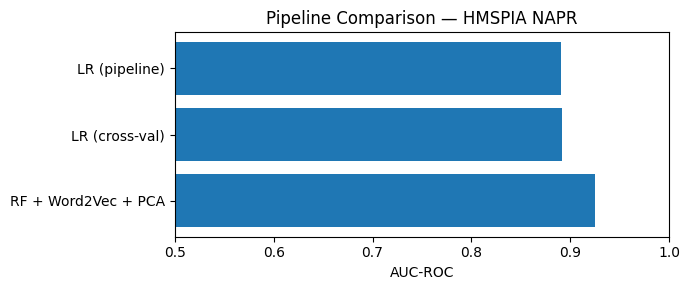

In [74]:
pipeline_results = [
    ("LR (pipeline)",       auc_pipeline),
    ("LR (cross-val)",      auc_cv),
    ("RF + Word2Vec + PCA", auc_w2v),
]

summary_df = spark.createDataFrame(pipeline_results, ["Model", "AUC_ROC"]) \
    .orderBy("AUC_ROC", ascending=False)
summary_df.show(truncate=False)

names  = [r["Model"]   for r in summary_df.collect()]
scores = [r["AUC_ROC"] for r in summary_df.collect()]

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(names, scores)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC-ROC")
ax.set_title("Pipeline Comparison — HMSPIA NAPR")
plt.tight_layout()
plt.show()